In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
try:
    import seaborn as sns
except ImportError as e:
    raise ImportError(
        "Seaborn is required for this notebook. Install it (e.g., `pip install seaborn`) and re-run."
    ) from e

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [4]:
df = pd.read_csv('data.csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,No,24,Venmo,Weekly


In [5]:
display(df.head())
print("shape:", df.shape)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


shape: (3900, 16)


In [6]:
print("Columns:")
for c in df.columns:
    print("-", c)
print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing").sort_values("missing", ascending=False))

print("\nDuplicate rows:", int(df.duplicated().sum()))
print("Duplicate Customer IDs:", int(df["Customer ID"].duplicated().sum()))
num_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
]
display(df[num_cols].describe().T)

Columns:
- Customer ID
- Age
- Gender
- Item Purchased
- Category
- Purchase Amount (USD)
- Location
- Size
- Color
- Season
- Review Rating
- Subscription Status
- Discount Applied
- Previous Purchases
- Payment Method
- Frequency of Purchases

Dtypes:


,dtype
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object



Missing values per column:


,missing
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0



Duplicate rows: 0
Duplicate Customer IDs: 0


,count,mean,std,min,25%,50%,75%,max
Age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.1,3.7,4.4,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0


In [7]:
age_bins = [18, 25, 35, 45, 55, 65, 71]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65–70"]
df["Age Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=False)
freq_to_per_year = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1,
}
df["Purchases/Year (Approx)"] = df["Frequency of Purchases"].map(freq_to_per_year)
season_order = ["Spring", "Summer", "Fall", "Winter"]
frequency_order = ["Weekly", "Bi-Weekly", "Fortnightly", "Monthly", "Every 3 Months", "Quarterly", "Annually"]

df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
df["Frequency of Purchases"] = pd.Categorical(df["Frequency of Purchases"], categories=frequency_order, ordered=True)

display(df[["Age", "Age Group", "Frequency of Purchases", "Purchases/Year (Approx)"]].head())

,Age,Age Group,Frequency of Purchases,Purchases/Year (Approx)
0,55,55–64,Fortnightly,26
1,19,18–24,Fortnightly,26
2,50,45–54,Weekly,52
3,21,18–24,Weekly,52
4,45,45–54,Annually,1


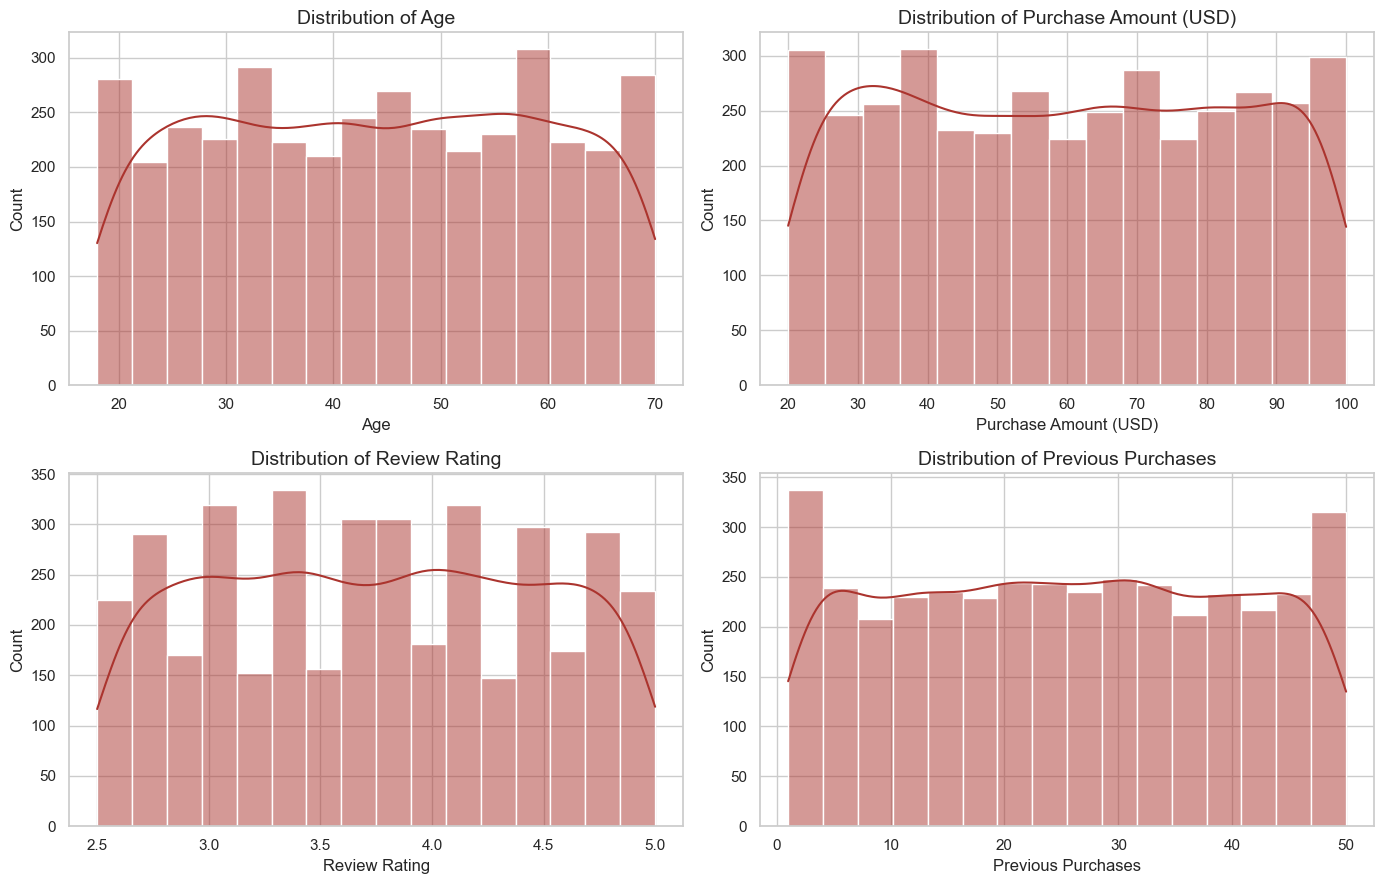

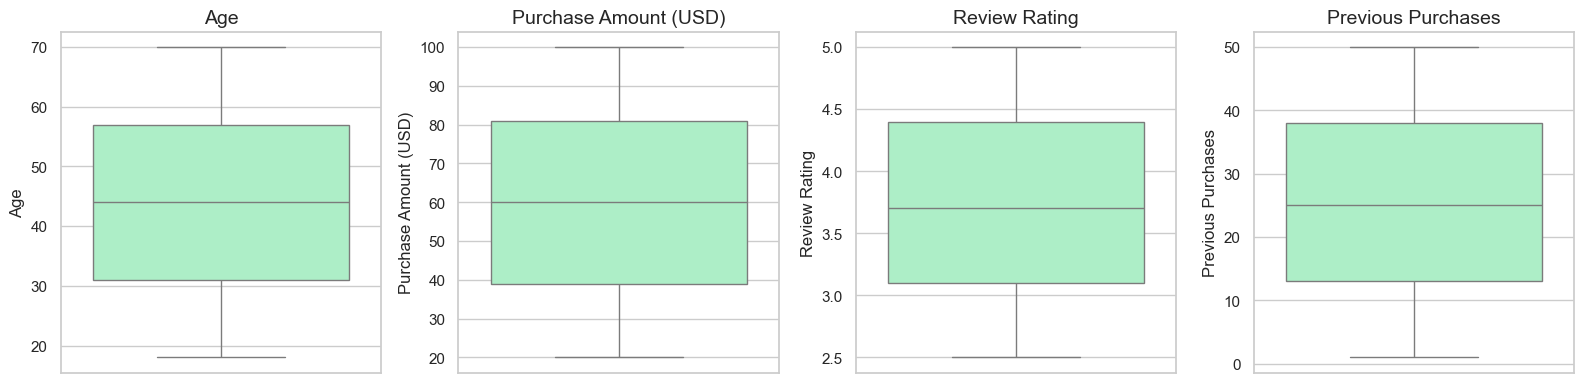

<Figure size 1000x500 with 0 Axes>

In [10]:
num_cols = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#AB342E")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Boxplots (quick outlier / spread check)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#A2F9C5")
    ax.set_title(col)
plt.tight_layout()
plt.show()
plt.savefig('numerical_distributions.png')

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/760777897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="viridis")
/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/760777897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="viridis")
/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/760777897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="vi

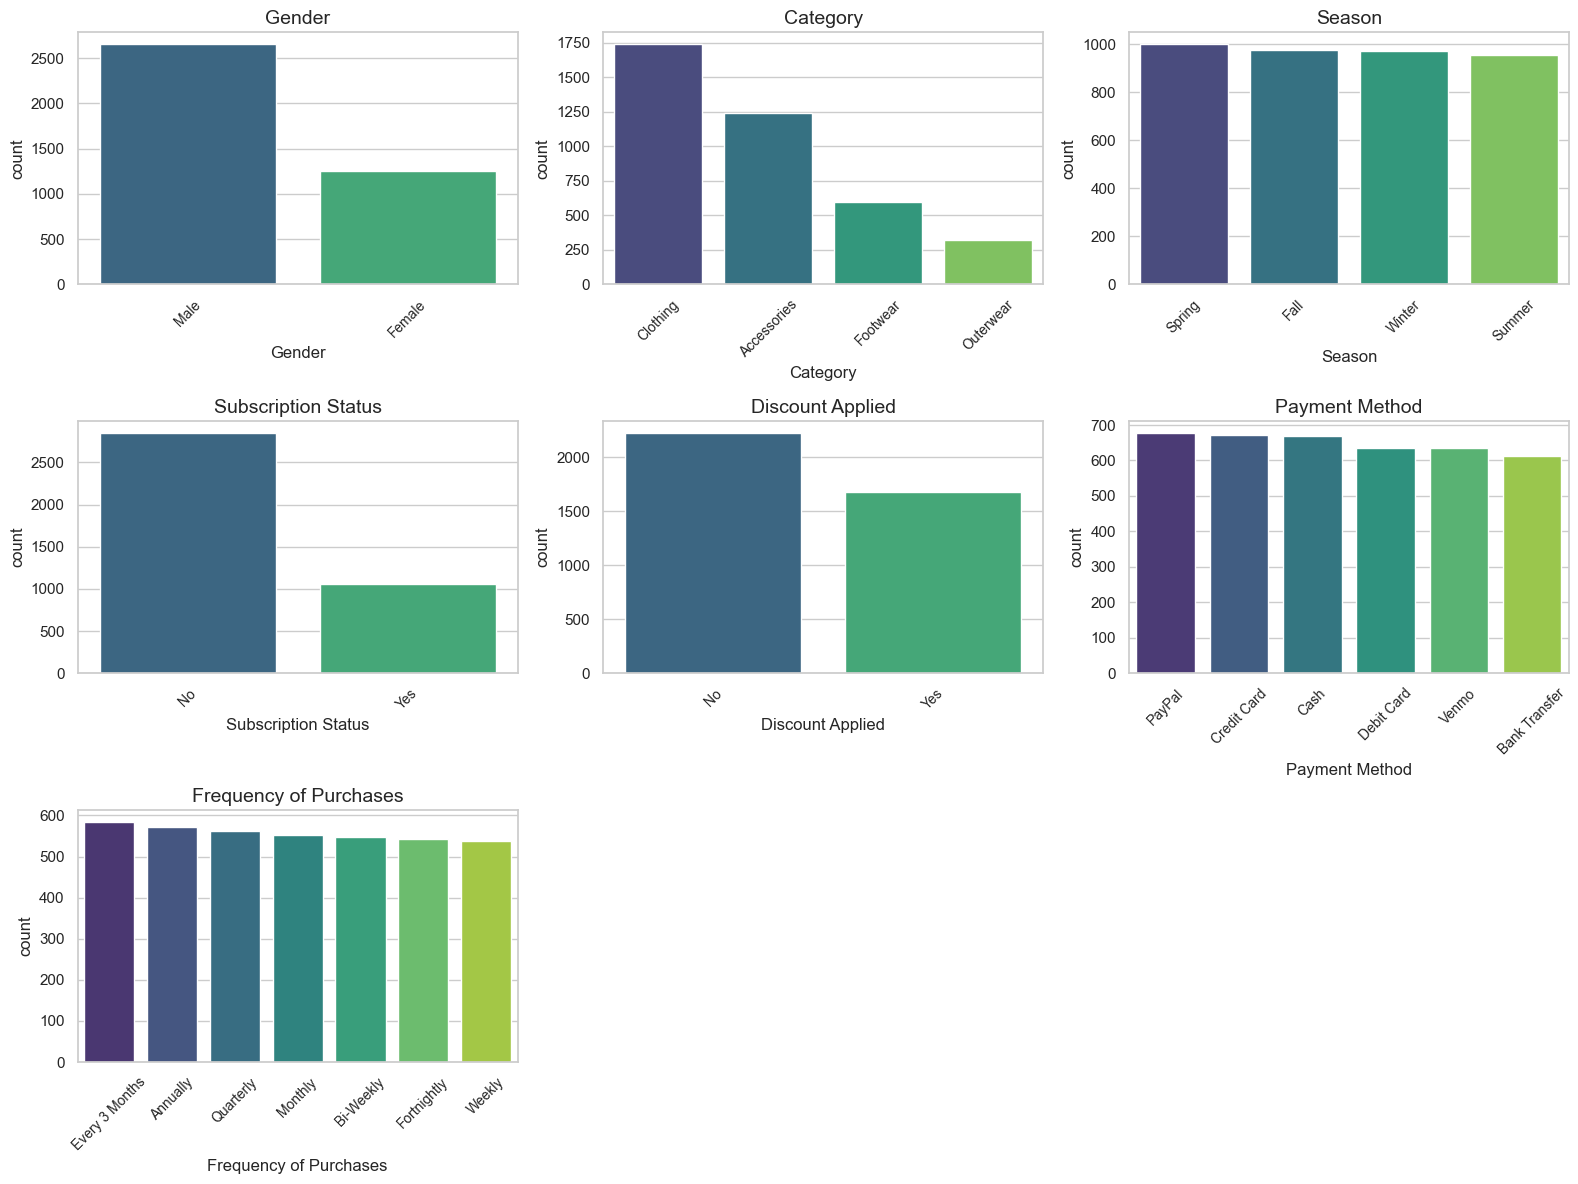

<Figure size 1000x500 with 0 Axes>

In [11]:
cat_cols = [
    "Gender",
    "Category",
    "Season",
    "Subscription Status",
    "Discount Applied",
    "Payment Method",
    "Frequency of Purchases",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45, labelsize=10)

for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
plt.savefig('categorical_distributions.png')

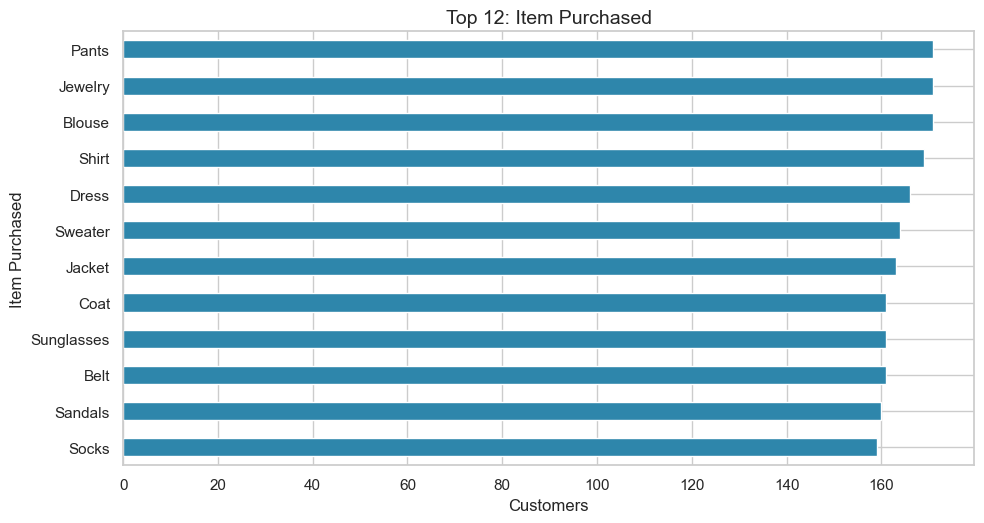

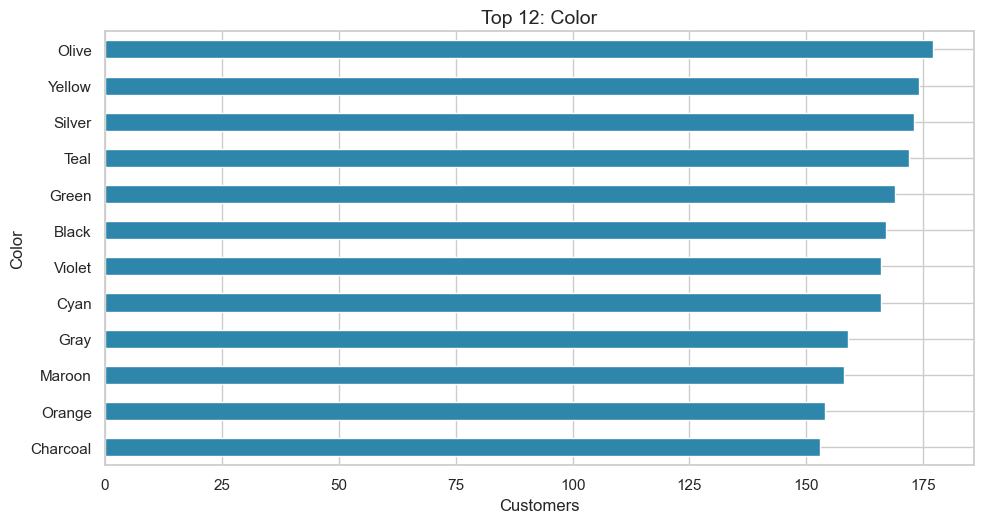

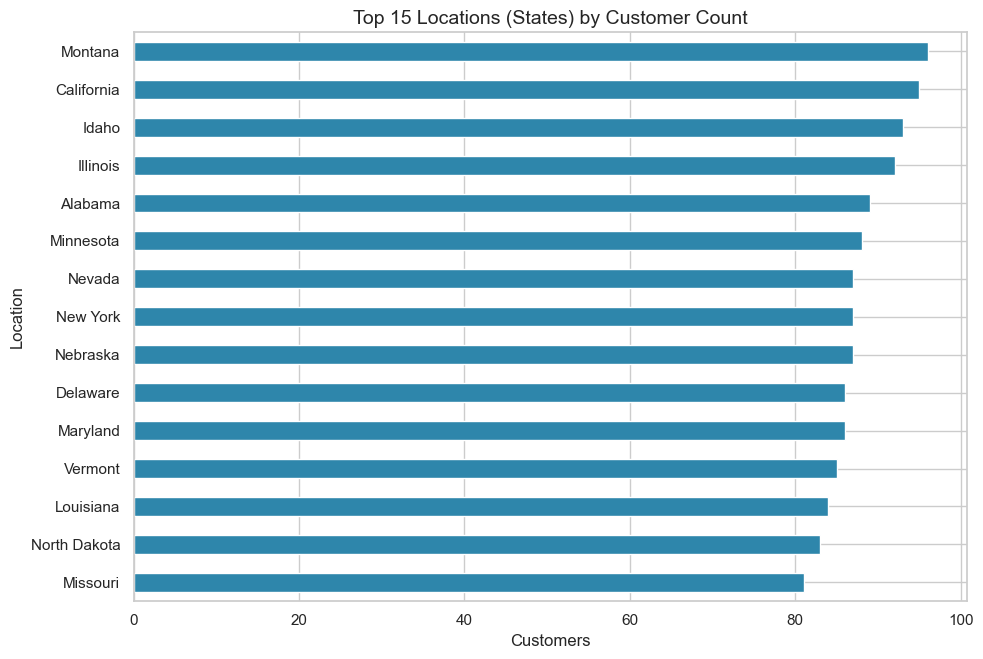

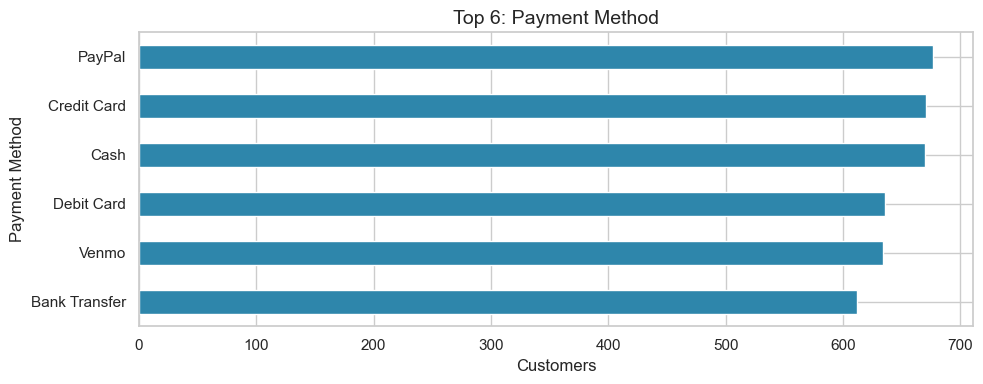

In [ ]:
def plot_top_n(col, n=10, title=None):
    vc = df[col].value_counts().head(n).sort_values()
    plt.figure(figsize=(10, max(4, n * 0.45)))
    vc.plot(kind="barh", color="#2E86AB")
    plt.title(title or f"Top {n}: {col}")
    plt.xlabel("Customers")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

plot_top_n("Item Purchased", n=12)
plot_top_n("Color", n=12)
plot_top_n("Location", n=15, title="Top 15 Locations (States) by Customer Count")
plot_top_n("Payment Method", n=6)

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/2457738830.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, order=order, ax=ax, showfliers=False, palette="Set2")
/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/2457738830.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, order=order, ax=ax, showfliers=False, palette="Set2")
/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/2457738830.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, 

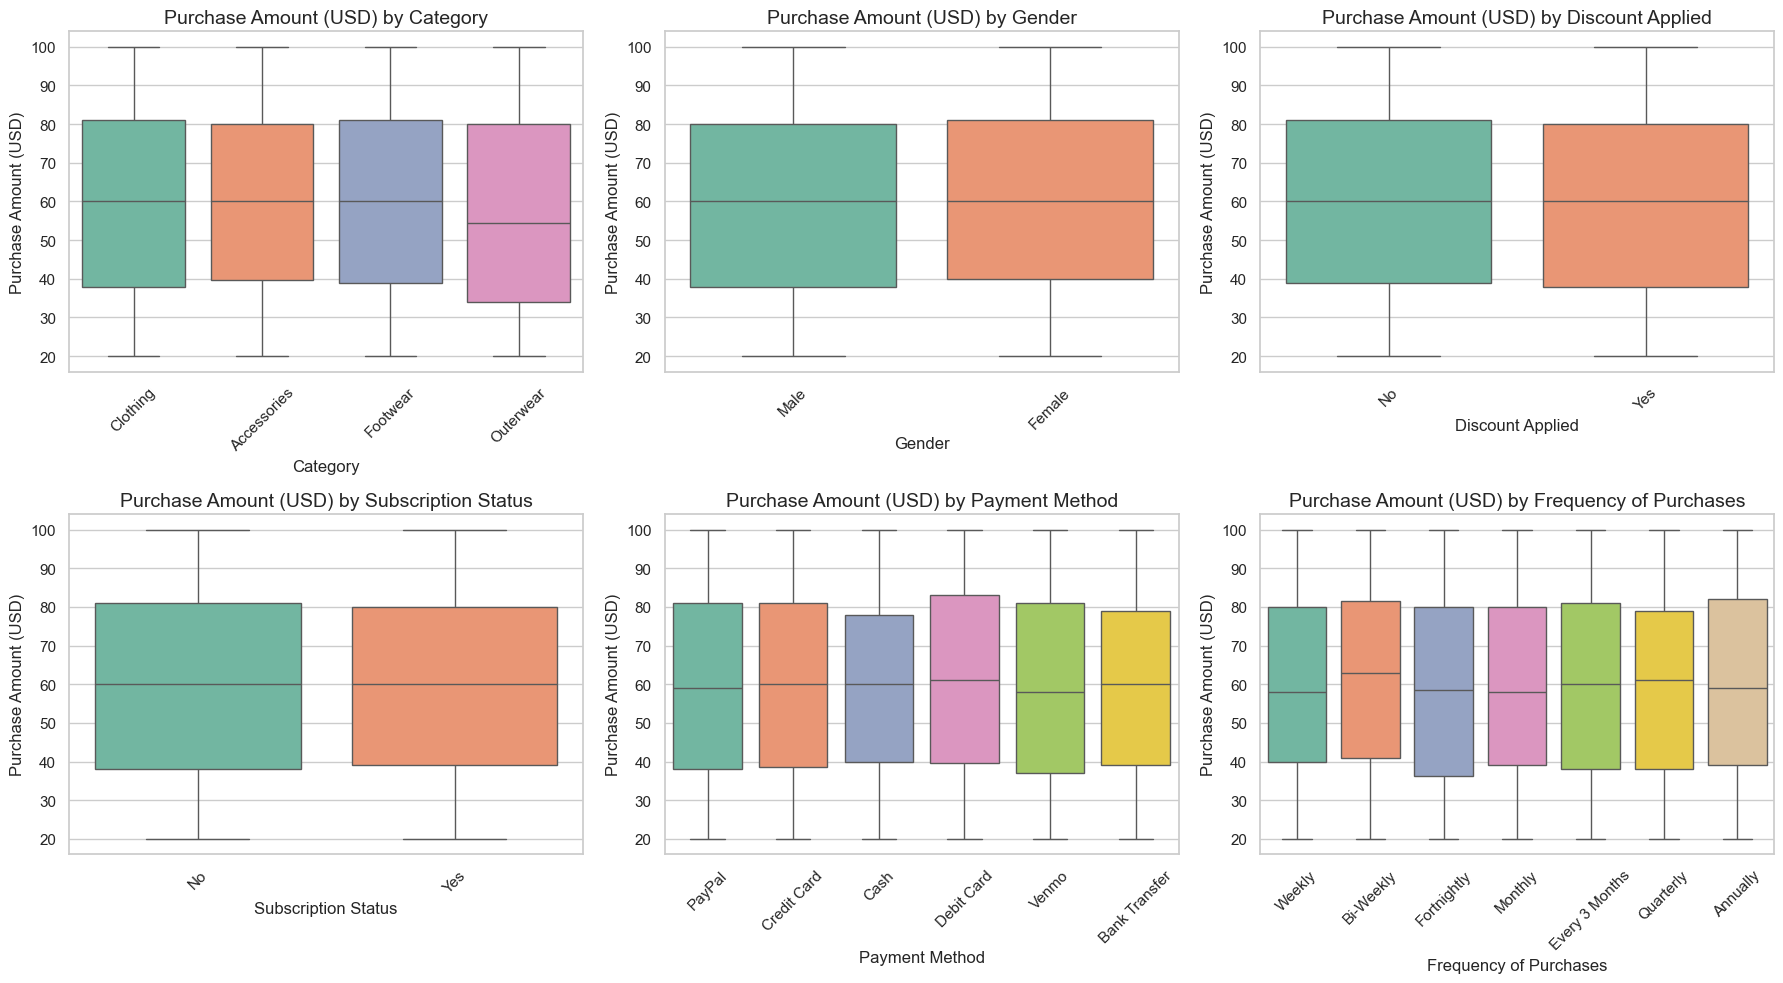

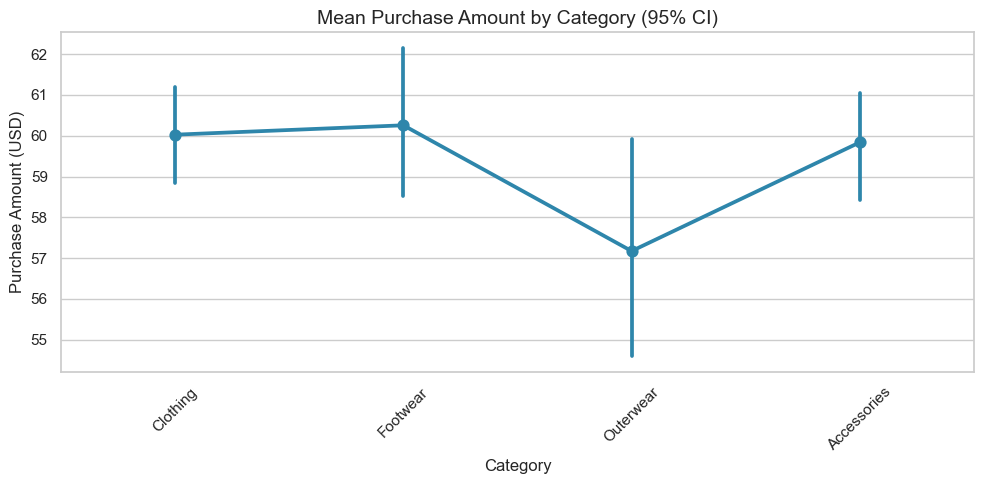

<Figure size 1000x500 with 0 Axes>

In [14]:
y = "Purchase Amount (USD)"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plots = [
    ("Category", None),
    ("Gender", None),
    ("Discount Applied", ["No", "Yes"]),
    ("Subscription Status", ["No", "Yes"]),
    ("Payment Method", None),
    ("Frequency of Purchases", list(df["Frequency of Purchases"].cat.categories)),
]

for ax, (x, order) in zip(axes, plots):
    if order is None:
        order = df[x].value_counts().index
    sns.boxplot(data=df, x=x, y=y, order=order, ax=ax, showfliers=False, palette="Set2")
    ax.set_title(f"{y} by {x}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Mean purchase amount (with 95% CI) for quick comparison
plt.figure(figsize=(10, 5))
sns.pointplot(data=df, x="Category", y=y, errorbar=("ci", 95), color="#2E86AB")
plt.title("Mean Purchase Amount by Category (95% CI)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_by_category.png')

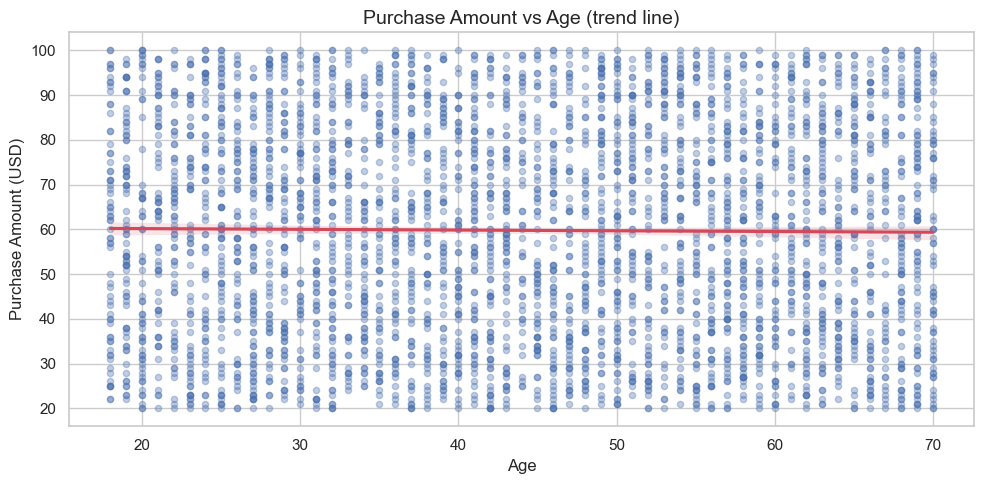

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/1696413603.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Age Group", y="Purchase Amount (USD)", showfliers=False, palette="Blues")


<Figure size 1000x500 with 0 Axes>

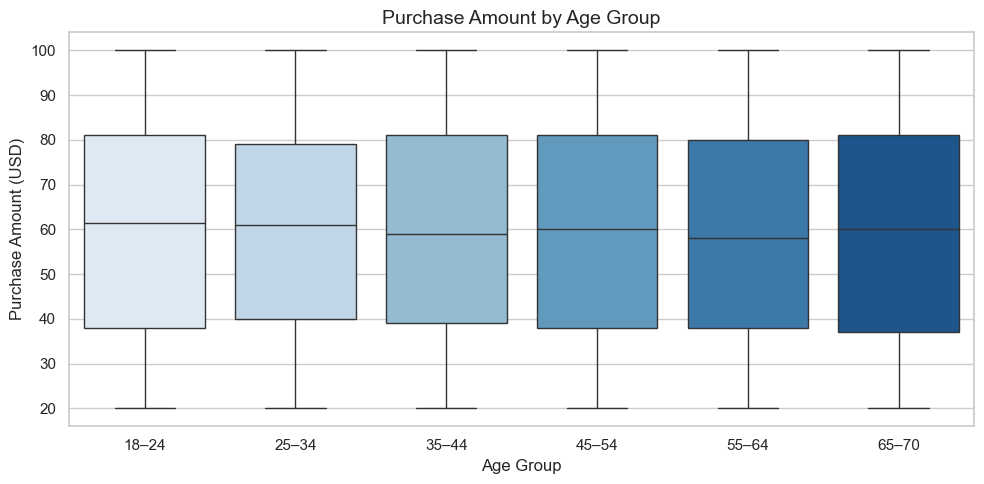

<Figure size 1000x500 with 0 Axes>

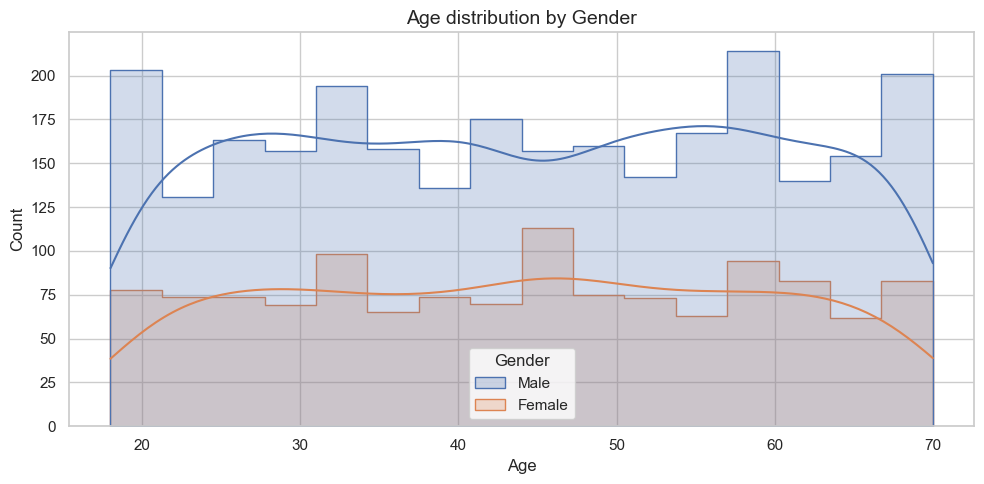

<Figure size 1000x500 with 0 Axes>

In [15]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x="Age", y="Purchase Amount (USD)", scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "#D1495B"})
plt.title("Purchase Amount vs Age (trend line)")
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_vs_age.png')

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Age Group", y="Purchase Amount (USD)", showfliers=False, palette="Blues")
plt.title("Purchase Amount by Age Group")
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_by_age_group.png')

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Gender", kde=True, element="step")
plt.title("Age distribution by Gender")
plt.tight_layout()
plt.show()
plt.savefig('age_distribution_by_gender.png')

,count,mean,median,mean_diff_vs_no,median_diff_vs_no
Discount Applied,,,,,
No,2223,60.130454,60.0,0.000000,0.0
Yes,1677,59.279070,60.0,-0.851385,0.0


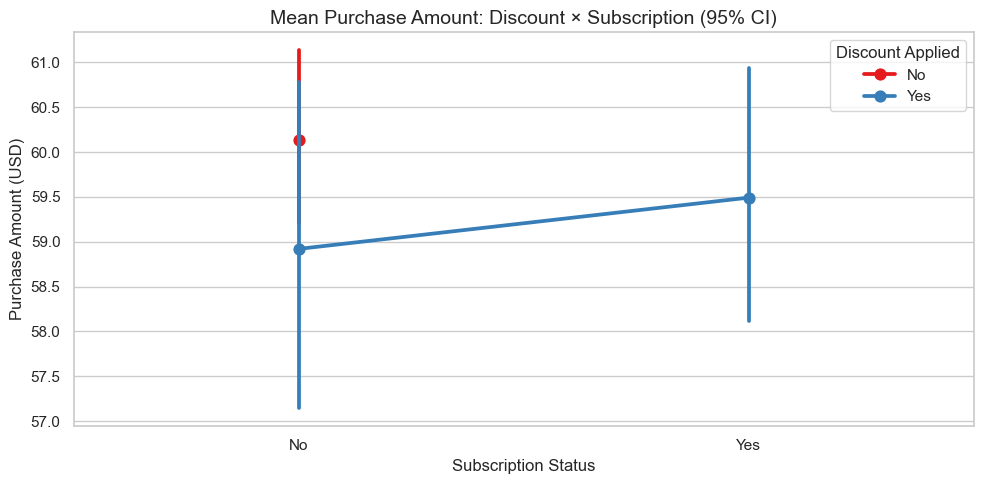

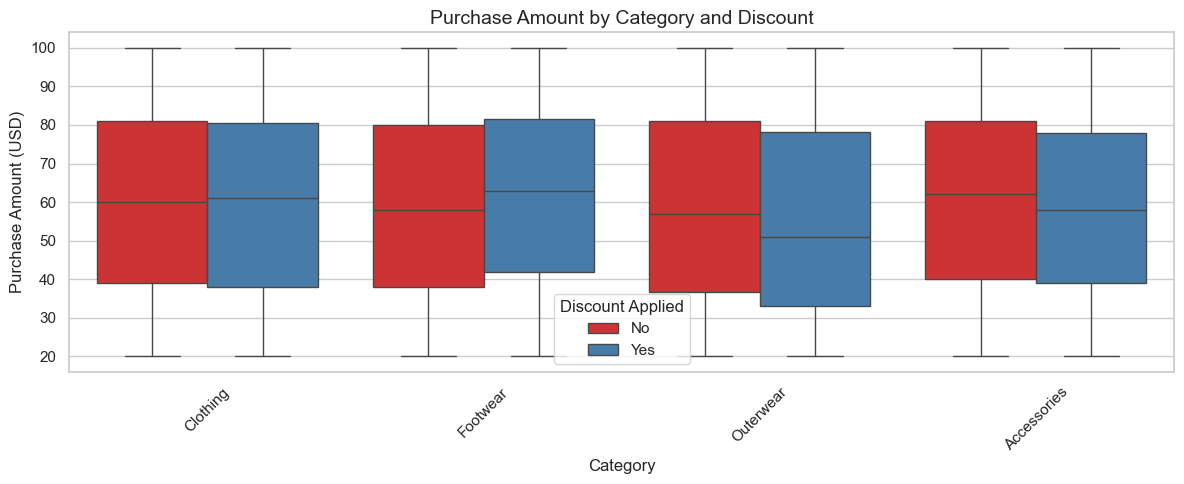

<Figure size 1000x500 with 0 Axes>

In [16]:
y = "Purchase Amount (USD)"

summary = (
    df.groupby("Discount Applied")[y]
    .agg(["count", "mean", "median"])
    .sort_index()
)
summary["mean_diff_vs_no"] = summary["mean"] - summary.loc["No", "mean"]
summary["median_diff_vs_no"] = summary["median"] - summary.loc["No", "median"]

display(summary)

plt.figure(figsize=(10, 5))
sns.pointplot(
    data=df,
    x="Subscription Status",
    y=y,
    hue="Discount Applied",
    order=["No", "Yes"],
    hue_order=["No", "Yes"],
    errorbar=("ci", 95),
    palette="Set1",
)
plt.title("Mean Purchase Amount: Discount × Subscription (95% CI)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df,
    x="Category",
    y=y,
    hue="Discount Applied",
    hue_order=["No", "Yes"],
    showfliers=False,
    palette="Set1",
)
plt.title("Purchase Amount by Category and Discount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_by_category.png')

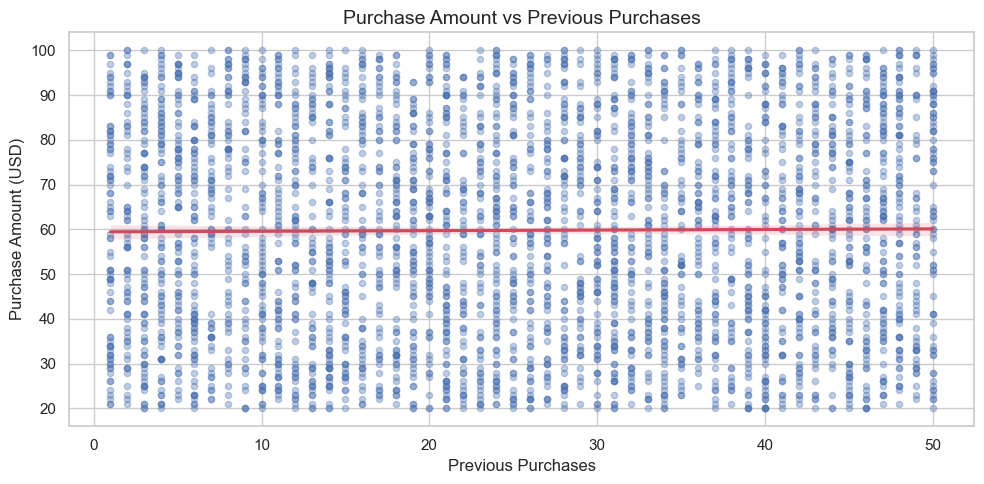

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_64228/2811456339.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 1000x500 with 0 Axes>

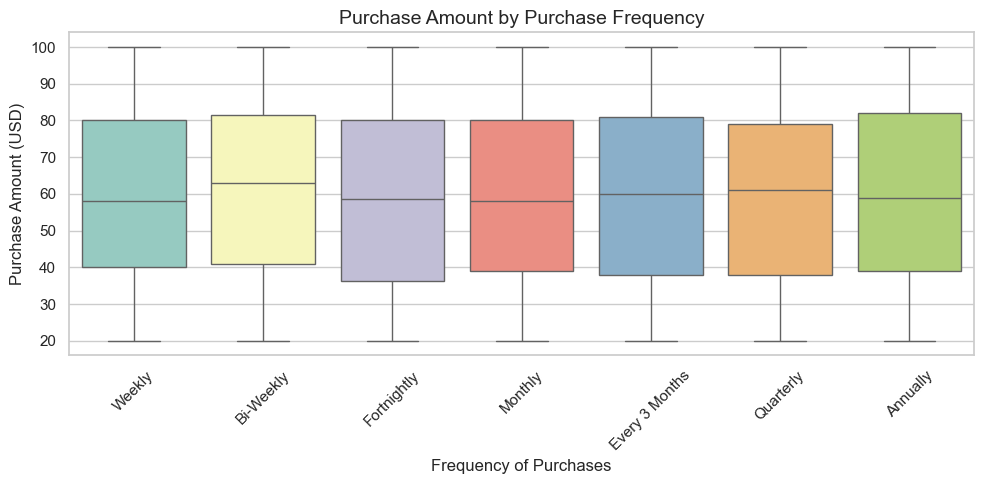

<Figure size 1000x500 with 0 Axes>

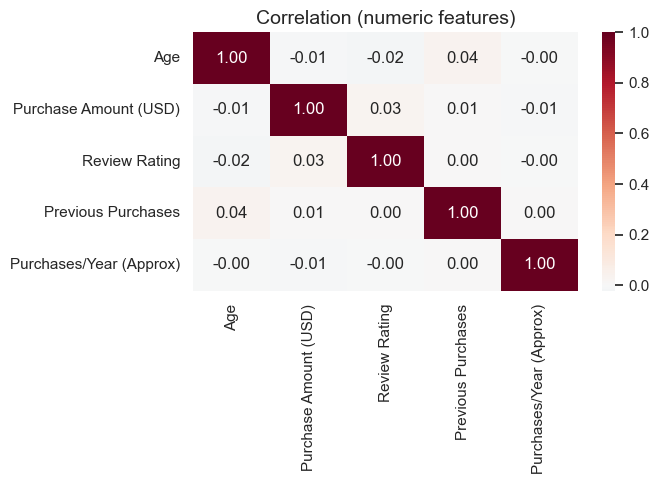

<Figure size 1000x500 with 0 Axes>

In [17]:
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df,
    x="Previous Purchases",
    y="Purchase Amount (USD)",
    scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"color": "#D1495B"},
)
plt.title("Purchase Amount vs Previous Purchases")
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_vs_previous_purchases.png')

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Frequency of Purchases",
    y="Purchase Amount (USD)",
    order=list(df["Frequency of Purchases"].cat.categories),
    showfliers=False,
    palette="Set3",
)
plt.title("Purchase Amount by Purchase Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('purchase_amount_by_purchase_frequency.png')

num_for_corr = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases", "Purchases/Year (Approx)"]
corr = df[num_for_corr].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation (numeric features)")
plt.tight_layout()
plt.show()
plt.savefig('correlation_heatmap.png')

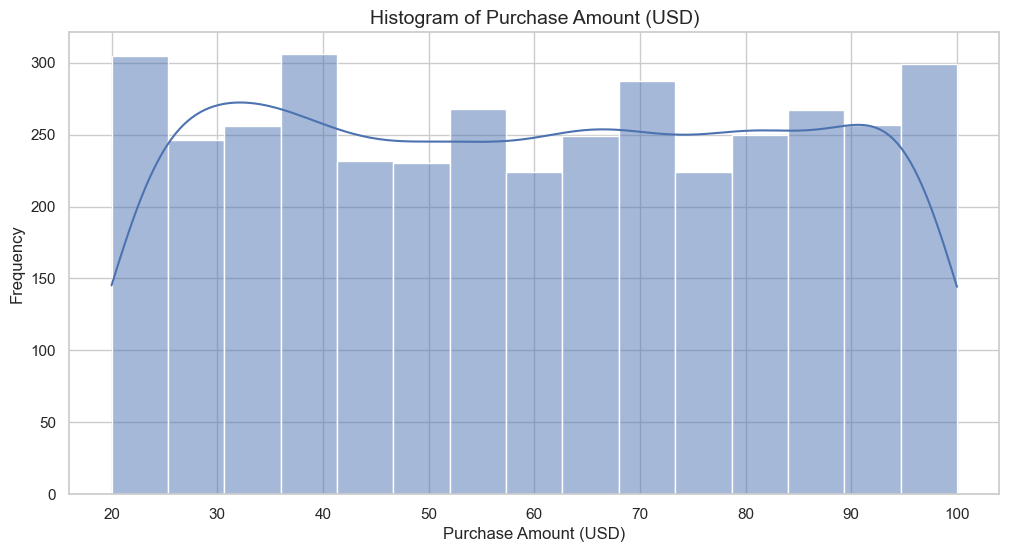

<Figure size 1000x500 with 0 Axes>

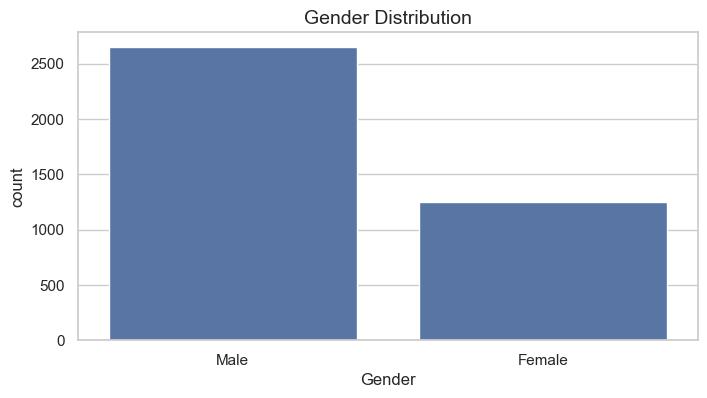

<Figure size 1000x500 with 0 Axes>

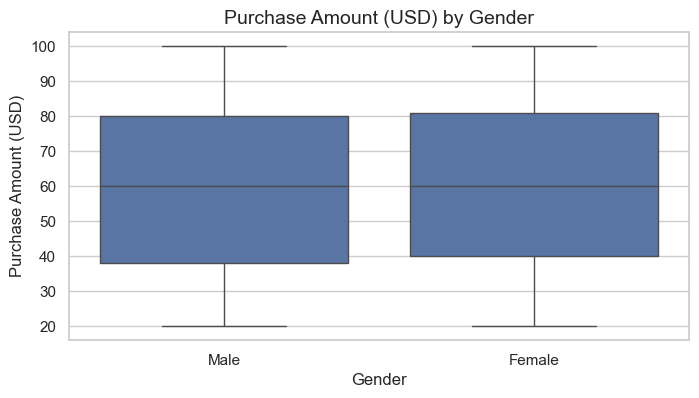

<Figure size 1000x500 with 0 Axes>

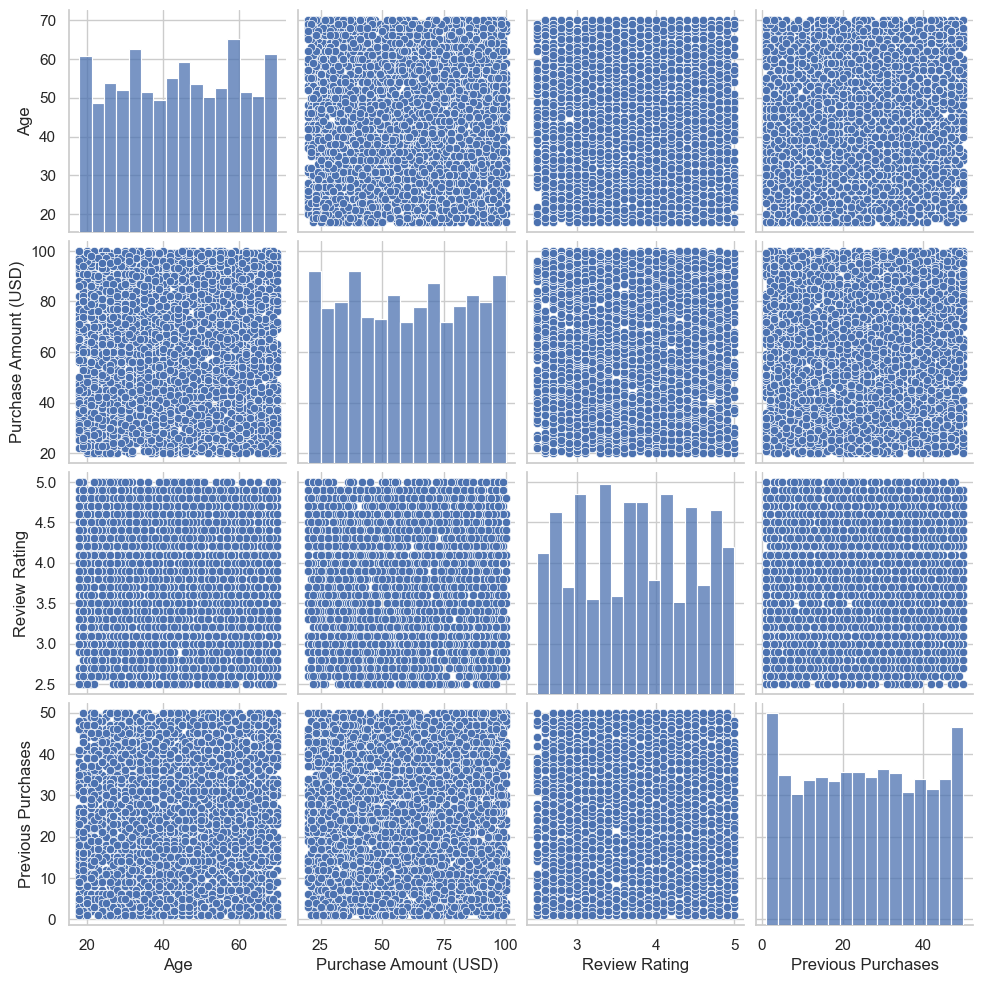

<Figure size 1000x500 with 0 Axes>

In [20]:
plt.figure(figsize=(12, 6))

sns.histplot(df['Purchase Amount (USD)'], kde=True)
plt.title('Histogram of Purchase Amount (USD)')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.show()
plt.savefig('histogram_purchase_amount.png')

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()
plt.savefig('gender_distribution.png')

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Gender', y='Purchase Amount (USD)')
plt.title('Purchase Amount (USD) by Gender')
plt.show()
plt.savefig('purchase_amount_by_gender.png')

sns.pairplot(df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']])
plt.show()
plt.savefig('pairplot_numeric_features.png')

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [23]:
features = df.drop(columns=['Customer ID', 'Purchase Amount (USD)'])
target = df['Purchase Amount (USD)']

features_encoded = pd.get_dummies(features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(features_encoded, target, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)
print('R2 Score for Purchase Amount Prediction:', score)

R2 Score for Purchase Amount Prediction: -0.02321550765113911
